# OpenCV Experiments

**Student Name:** Muhammad Hassan

**Registration No.:** 2023-bs-ai-176

**Fellowship Organization:** Visbility Bots

## Aim
To perform basic image processing operations using OpenCV and understand how these techniques are used in computer vision.


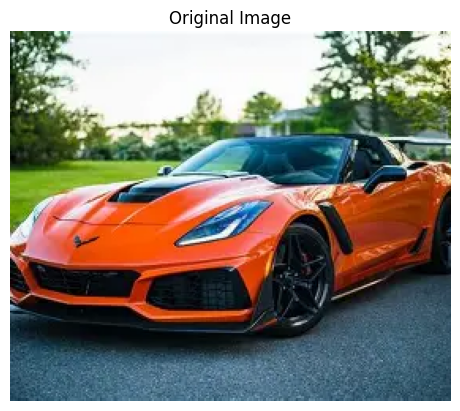

In [2]:
import cv2
import matplotlib.pyplot as plt

img=cv2.imread("/content/OIP (2).webp")
if img is None:
    raise FileNotFoundError("Place image.jpg in the notebook folder.")
img_rgb=cv2.cvtColor(img,cv2.COLOR_BGR2RGB)
plt.imshow(img_rgb); plt.title("Original Image"); plt.axis("off"); plt.show()


## Experiment 1: Color Space Conversion

**Objective:** Convert an image into RGB, Grayscale and HSV.

**Explanation:**
A digital image can be represented in different color spaces depending on the application. OpenCV stores images in BGR format by default, but they can be converted to Grayscale for intensity-based processing or HSV for color-based analysis. Converting between color spaces allows computer vision algorithms to extract useful information more efficiently.

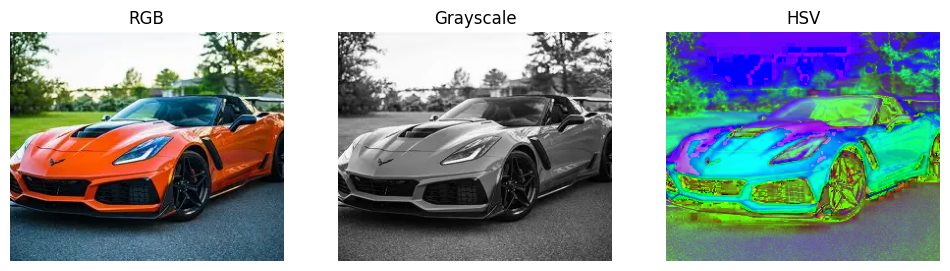

In [3]:
gray=cv2.cvtColor(img,cv2.COLOR_BGR2GRAY)
hsv=cv2.cvtColor(img,cv2.COLOR_BGR2HSV)
fig,ax=plt.subplots(1,3,figsize=(12,4));ax[0].imshow(img_rgb);ax[0].set_title('RGB');ax[1].imshow(gray,cmap='gray');ax[1].set_title('Grayscale');ax[2].imshow(hsv);ax[2].set_title('HSV');[a.axis('off') for a in ax];plt.show()

## Experiment 2: Image Filtering

**Objective:** Apply different filters to reduce noise.

**Explanation:**
Image filtering smooths an image by reducing unwanted noise while preserving important details. Average, Gaussian and Median filters use different mathematical approaches to replace pixel values based on neighboring pixels, making later tasks like edge or object detection more accurate.

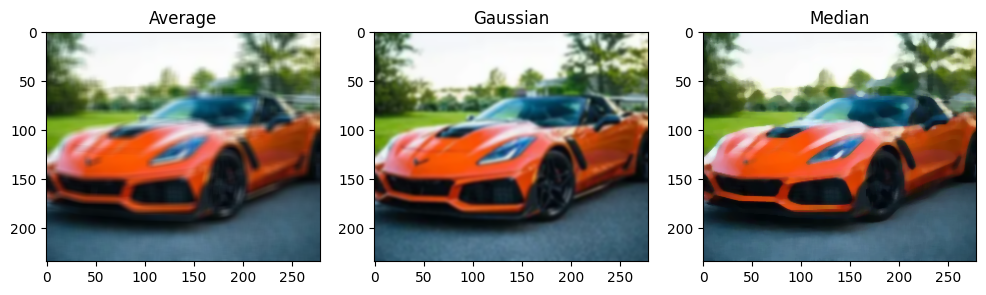

In [9]:
avg=cv2.blur(img_rgb,(7,7));g=cv2.GaussianBlur(img_rgb,(7,7),0);m=cv2.medianBlur(img_rgb,7)
fig,ax=plt.subplots(1,3,figsize=(12,4));
for a,i,t in zip(ax,[avg,g,m],['Average','Gaussian','Median']): a.imshow(i);a.set_title(t);a.axis('on')
plt.show()

## Experiment 3: Edge Detection

**Objective:** Detect object boundaries using Canny.

**Explanation:**
Edge detection identifies locations where pixel intensity changes sharply, which usually correspond to object boundaries. The Canny algorithm first removes noise, calculates intensity gradients, and then keeps only the strongest edges, making it one of the most reliable edge detection methods.

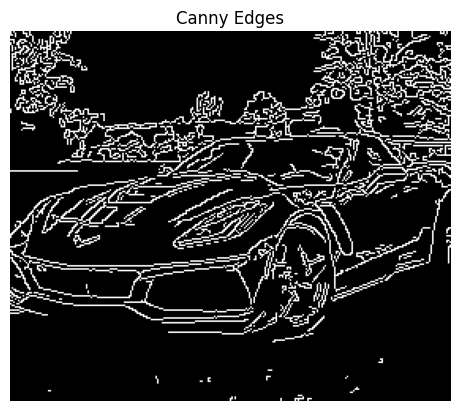

In [13]:
edges=cv2.Canny(gray,140,250);plt.imshow(edges,cmap='gray');plt.title('Canny Edges');plt.axis('off');plt.show()

## Experiment 4: Contour Detection

**Objective:** Detect the outlines of objects.

**Explanation:**
Contours are continuous curves that join points with the same boundary, representing the shape of an object. After edge detection, OpenCV traces these boundaries and returns them as contours, which are useful for object counting, measurement and recognition.

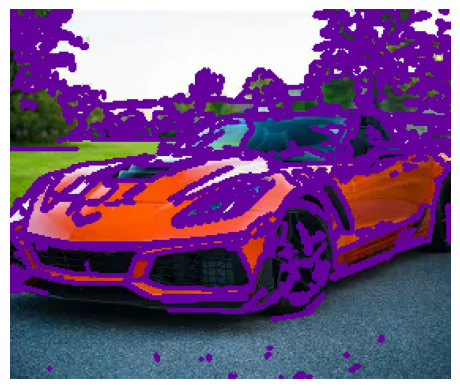

258


In [16]:
contours,_=cv2.findContours(edges,cv2.RETR_EXTERNAL,cv2.CHAIN_APPROX_SIMPLE);
out=img_rgb.copy();cv2.drawContours(out,contours,-1,(100,0,155),2);plt.imshow(out);plt.axis('off');plt.show();print(len(contours))

## Experiment 5: Shape Detection

**Objective:** Recognize simple geometric shapes.

**Explanation:**
Shape detection works by approximating each contour into a polygon. The number of polygon sides is then used to classify the object as a triangle, rectangle, pentagon or circle, making it useful in automation and object recognition systems.

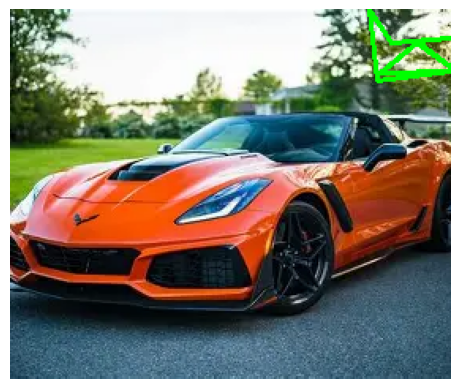

In [17]:
out=img_rgb.copy()
for c in contours:
    if cv2.contourArea(c)<500: continue
    a=cv2.approxPolyDP(c,0.02*cv2.arcLength(c,True),True);x,y,w,h=cv2.boundingRect(a);s=len(a);name='Circle'
    if s==3:name='Triangle'
    elif s==4:name='Rectangle/Square'
    elif s==5:name='Pentagon'
    cv2.drawContours(out,[a],-1,(0,255,0),2);cv2.putText(out,name,(x,y-5),0,0.5,(255,0,0),2)
plt.imshow(out);plt.axis('off');plt.show()

## Conclusion
These experiments demonstrate the basic image processing techniques provided by OpenCV. Color conversion, filtering, edge detection, contour detection and shape detection are fundamental operations used in applications such as object detection, medical imaging, robotics and artificial intelligence.